# 03 · Social Media Analysis
**UK Premium Kidswear & Teen Apparel — E-commerce Market Entry Analysis**

---

### Objective
Analyse the social media presence of 11 competitor brands across Instagram and TikTok to understand:
- Platform scale and follower distribution by market segment
- Engagement rate vs follower count (quality vs quantity of audience)
- Content format strategy (Reels vs Carousel vs Static)
- Follower/Following ratio as a brand maturity signal
- TikTok vs Instagram balance and cross-platform reach
- Strategic positioning of Pink Palm Puff as TikTok-native case study

### Data
- **Source**: Manual collection from public Instagram and TikTok profiles, February 2026
- **Brands**: 11 brands across UK mass market, UK premium, US premium, AU/Global premium
- **File**: `social_media_data_collection_v7.xlsx`
- **Engagement rate**: Weighted average across all content formats with visible likes

### Methodology note
Engagement rate = total weighted likes across all format types (carousel, reels, static) ÷ total counted posts ÷ followers × 100. Brands with all likes hidden are excluded from engagement charts (Mini Boden, Petite Plume, Pink Chicken). D&D likes visible on influencer UGC carousel posts only.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# ── Notebook-wide style ────────────────────────────────────────────────────
plt.rcParams.update({
    'font.family':       'Arial',
    'font.size':         11,
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.titleweight':  'bold',
    'axes.titlepad':     14,
    'axes.labelsize':    10,
    'figure.dpi':        130,
    'savefig.dpi':       150,
    'savefig.bbox':      'tight',
})

# ── Colour palette ─────────────────────────────────────────────────────────
COLOURS = {
    'mass':       '#B0BEC5',   # grey-blue — mass market
    'premium_uk': '#1565C0',   # deep blue — UK premium
    'premium_us': '#2E7D32',   # deep green — US premium
    'premium_au': '#F57F17',   # amber — AU/Global
    'ppp':        '#AD1457',   # deep pink — Pink Palm Puff highlight
    'accent':     '#1F3864',   # navy — headers
}

SEGMENT_COLOUR = {
    'M&S':               COLOURS['mass'],
    'Next':              COLOURS['mass'],
    'Mini Boden':        COLOURS['premium_uk'],
    'Desmond & Dempsey': COLOURS['premium_uk'],
    'Babble & Goose':    COLOURS['premium_uk'],
    'White Fox':         COLOURS['premium_au'],
    'Roller Rabbit':     COLOURS['premium_us'],
    'Posh Peanut':       COLOURS['premium_us'],
    'Petite Plume':      COLOURS['premium_us'],
    'Pink Chicken':      COLOURS['premium_us'],
    'Pink Palm Puff':    COLOURS['ppp'],
}

print('Libraries loaded ✓')

Libraries loaded ✓


In [2]:
# ── Load data ──────────────────────────────────────────────────────────────
FILE = 'social_media_data_collection_v7.xlsx'

ig_raw = pd.read_excel(FILE, sheet_name='Instagram', header=3, nrows=11)
tt_raw = pd.read_excel(FILE, sheet_name='TikTok',    header=2, nrows=11)

# ── Instagram ──────────────────────────────────────────────────────────────
ig = ig_raw[[
    ig_raw.columns[0],   # Brand
    ig_raw.columns[1],   # Market
    ig_raw.columns[2],   # Positioning
    ig_raw.columns[4],   # Followers
    ig_raw.columns[5],   # Following
    ig_raw.columns[6],   # Ratio
    ig_raw.columns[7],   # Total Posts
    ig_raw.columns[8],   # Reels
    ig_raw.columns[9],   # Static
    ig_raw.columns[10],  # Carousel
    ig_raw.columns[11],  # Avg Carousel Likes
    ig_raw.columns[12],  # Avg Reel Likes
    ig_raw.columns[13],  # Engagement Rate
    ig_raw.columns[14],  # Kids/Teen
]].copy()

ig.columns = ['brand','market','positioning','ig_followers','ig_following',
              'ratio','total_posts','reels','static','carousel',
              'avg_car_likes','avg_reel_likes','eng_rate','kids_teen']

# Coerce numerics — hidden likes become NaN
for col in ['ig_followers','ig_following','ratio','total_posts',
            'reels','static','carousel','avg_car_likes','avg_reel_likes','eng_rate']:
    ig[col] = pd.to_numeric(ig[col], errors='coerce')

ig['colour'] = ig['brand'].map(SEGMENT_COLOUR)

# ── TikTok ─────────────────────────────────────────────────────────────────
tt = tt_raw[[
    tt_raw.columns[0],   # Brand
    tt_raw.columns[1],   # Market
    tt_raw.columns[3],   # Followers
    tt_raw.columns[4],   # Following
    tt_raw.columns[5],   # Total Videos
    tt_raw.columns[6],   # Total Likes (profile)
    tt_raw.columns[10],  # Avg Views
]].copy()

tt.columns = ['brand','market','tt_followers','tt_following','tt_videos','tt_total_likes','tt_avg_views']

for col in ['tt_followers','tt_following','tt_videos','tt_total_likes','tt_avg_views']:
    tt[col] = pd.to_numeric(tt[col], errors='coerce')

# ── Merge ──────────────────────────────────────────────────────────────────
df = ig.merge(tt[['brand','tt_followers','tt_following','tt_videos',
                   'tt_total_likes','tt_avg_views']], on='brand', how='left')

df['total_followers'] = df['ig_followers'].fillna(0) + df['tt_followers'].fillna(0)

# Ordering: mass first, then premium by IG followers desc
ORDER = ['M&S','Next','White Fox','Posh Peanut','Pink Palm Puff',
         'Roller Rabbit','Mini Boden','Petite Plume','Desmond & Dempsey',
         'Pink Chicken','Babble & Goose']
df['order'] = df['brand'].map({b:i for i,b in enumerate(ORDER)})
df = df.sort_values('order').reset_index(drop=True)

print(f'Loaded {len(df)} brands')
print(df[['brand','ig_followers','tt_followers','eng_rate']].to_string(index=False))

Loaded 11 brands
            brand  ig_followers  tt_followers  eng_rate
              M&S       2400000        144300     0.048
             Next       3400000        233900     0.019
        White Fox       2700000       1500000     0.062
      Posh Peanut        777000         71700     0.056
   Pink Palm Puff        676000        967400     2.366
    Roller Rabbit        258000        187300     1.157
       Mini Boden        213000          8916       NaN
     Petite Plume        156000         15200       NaN
Desmond & Dempsey        152000          1022     0.197
     Pink Chicken        139000          4541       NaN
   Babble & Goose         63800         70100     0.182


---
## Chart 1 · Instagram Followers by Brand
Scale comparison across mass market and premium segments.

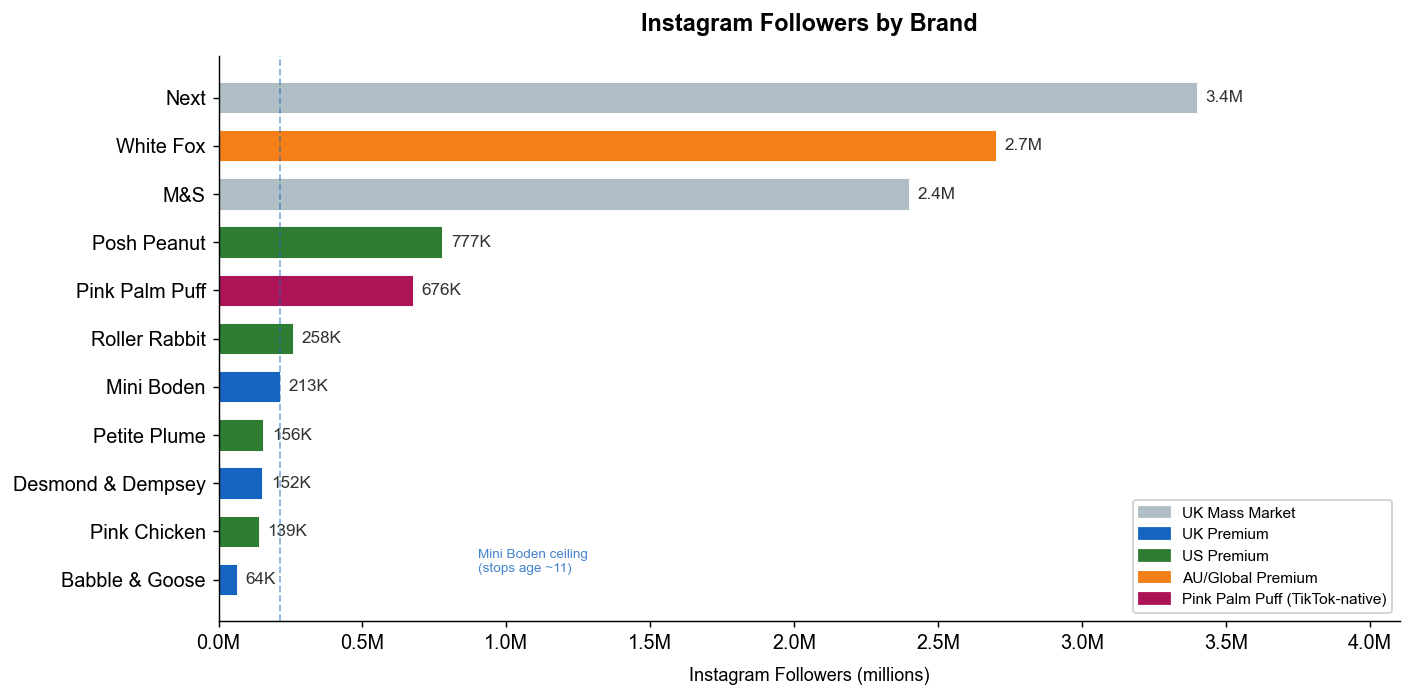

Saved: chart1_ig_followers.png


In [3]:
fig, ax = plt.subplots(figsize=(11, 5.5))

# Sort by IG followers descending for this chart
d = df.sort_values('ig_followers', ascending=True)

bars = ax.barh(d['brand'], d['ig_followers'] / 1e6,
               color=d['colour'], edgecolor='white', linewidth=0.5, height=0.65)

# Value labels
for bar, val in zip(bars, d['ig_followers']):
    label = f'{val/1e6:.1f}M' if val >= 1e6 else f'{val/1e3:.0f}K'
    ax.text(bar.get_width() + 0.03, bar.get_y() + bar.get_height()/2,
            label, va='center', ha='left', fontsize=9.5, color='#333333')

ax.set_xlabel('Instagram Followers (millions)', labelpad=8)
ax.set_title('Instagram Followers by Brand', pad=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.set_xlim(0, ax.get_xlim()[1] * 1.15)

# Legend
legend_items = [
    mpatches.Patch(color=COLOURS['mass'],       label='UK Mass Market'),
    mpatches.Patch(color=COLOURS['premium_uk'], label='UK Premium'),
    mpatches.Patch(color=COLOURS['premium_us'], label='US Premium'),
    mpatches.Patch(color=COLOURS['premium_au'], label='AU/Global Premium'),
    mpatches.Patch(color=COLOURS['ppp'],        label='Pink Palm Puff (TikTok-native)'),
]
ax.legend(handles=legend_items, loc='lower right', fontsize=8.5,
          framealpha=0.9, edgecolor='#cccccc')

# Annotation: gap
ax.axvline(x=0.213, color='#1565C0', linewidth=1, linestyle='--', alpha=0.5)
ax.text(0.22, 0.15, 'Mini Boden ceiling\n(stops age ~11)',
        transform=ax.get_yaxis_transform(), fontsize=7.5, color='#1565C0', alpha=0.8)

plt.tight_layout()
plt.savefig('chart1_ig_followers.png')
plt.show()
print('Saved: chart1_ig_followers.png')

Mass market brands capture the most attention on instagram (M&S and Next) while most premium players remain sub-300k.  The visual gap between the top 3-5 brands shows how difficult it is to scale an instagram audience in the kidswear/teen apparel without broad mass-market appeal or exceptional viral/content momentum like Pink Palm Puff on White Fox.  The Mini Boden age cap at 11 highlights the difficulty brands with a narrower product/age range face in viral/scalability potential vs those with broader appeal.

---
## Chart 2 · Engagement Rate vs Instagram Followers
The inverse relationship between scale and engagement — smaller premium brands punch above their weight.
Brands with all likes hidden excluded (Mini Boden, Petite Plume, Pink Chicken).

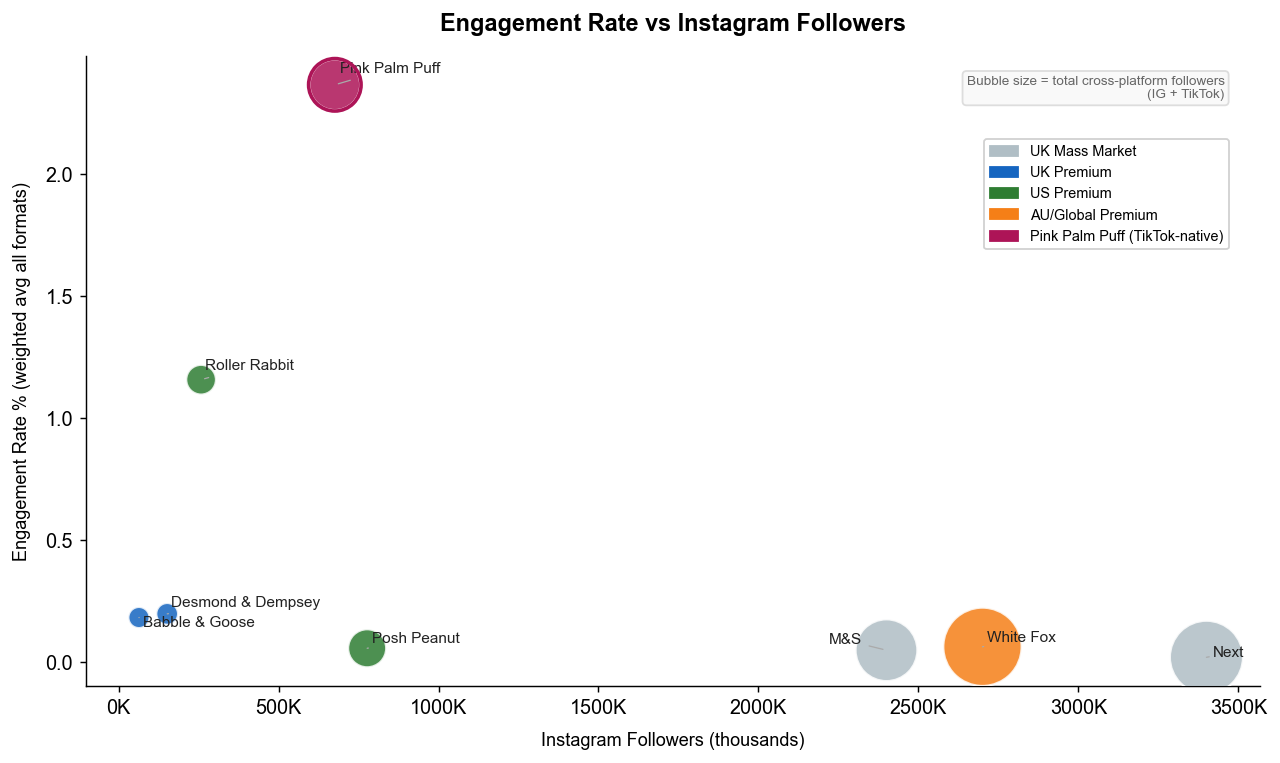

Saved: chart2_engagement_vs_followers.png


In [4]:
fig, ax = plt.subplots(figsize=(10, 6))

d = df.dropna(subset=['eng_rate'])

# Bubble size proportional to total cross-platform followers
sizes = (d['total_followers'] / d['total_followers'].max() * 1800) + 80

scatter = ax.scatter(
    d['ig_followers'] / 1e3,
    d['eng_rate'],
    s=sizes,
    c=d['colour'],
    alpha=0.85,
    edgecolors='white',
    linewidths=1.2,
    zorder=3
)

# Labels with offset logic to avoid overlap
offsets = {
    'Pink Palm Puff':    ( 15,  0.05),
    'Roller Rabbit':     ( 12,  0.04),
    'Babble & Goose':    ( 12, -0.04),
    'Desmond & Dempsey': ( 12,  0.03),
    'Posh Peanut':       ( 15,  0.02),
    'White Fox':         ( 15,  0.02),
    'M&S':               (-180, 0.025),
    'Next':              ( 20,  0.0),
}

for _, row in d.iterrows():
    ox, oy = offsets.get(row['brand'], (10, 0.02))
    ax.annotate(
        row['brand'],
        xy=(row['ig_followers']/1e3, row['eng_rate']),
        xytext=(row['ig_followers']/1e3 + ox, row['eng_rate'] + oy),
        fontsize=8.5,
        color='#222222',
        arrowprops=dict(arrowstyle='-', color='#aaaaaa', lw=0.7) if abs(ox) > 5 else None
    )

# Highlight PPP separately
ppp = d[d['brand'] == 'Pink Palm Puff'].iloc[0]
ax.scatter(ppp['ig_followers']/1e3, ppp['eng_rate'],
           s=sizes[d['brand']=='Pink Palm Puff'].values[0] + 60,
           facecolors='none', edgecolors=COLOURS['ppp'], linewidths=2, zorder=4)

ax.set_xlabel('Instagram Followers (thousands)', labelpad=8)
ax.set_ylabel('Engagement Rate % (weighted avg all formats)', labelpad=8)
ax.set_title('Engagement Rate vs Instagram Followers', pad=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))

# Trend annotation
ax.text(0.97, 0.97,
        'Bubble size = total cross-platform followers\n(IG + TikTok)',
        transform=ax.transAxes, ha='right', va='top',
        fontsize=7.5, color='#666666',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='#f9f9f9', edgecolor='#dddddd'))

ax.legend(handles=legend_items, fontsize=8, framealpha=0.9, edgecolor='#cccccc',
          loc='upper right', bbox_to_anchor=(0.98, 0.88))

plt.tight_layout()
plt.savefig('chart2_engagement_vs_followers.png')
plt.show()
print('Saved: chart2_engagement_vs_followers.png')

This scatter plot shows that while follower count signals visibility and maturity, true competitive edge in this space increasingly comes from engagement quality — and PPP is the standout proof that TikTok-native strategies can deliver both.

**Core pattern: Scale vs. quality trade-off**

- The vast majority of brands follow the expected downward-sloping trend:
Larger Instagram audiences (especially mass-market giants like Next ~3.4M, M&S ~2.4M, and White Fox ~2.7M) show very low engagement rates (clustered near or below 0.1–0.2%).
This is typical for broad-appeal, high-follower accounts — they achieve massive reach but dilute per-follower interaction due to less targeted/niche content, algorithmic saturation, or a more passive audience.

- Smaller-to-mid-sized premium brands generally achieve higher engagement (0.2–1.2% range), as they benefit from more loyal, niche communities that actively interact.

**Strategic takeaways**

- Engagement premium for smaller/viral-native players — Brands like PPP and Roller Rabbit prove that prioritizing content velocity, format innovation (Reels/short-form), and community resonance can yield 5–10× higher engagement than mass-market scale alone. This is especially powerful in teen/Gen Z/Gen Alpha apparel, where authenticity and virality trump sheer follower volume.

- Diminishing returns on pure follower growth — Once past ~1M IG followers, engagement drops sharply (near-flat at the right side of the chart). Growth strategies must shift toward retention/activation rather than acquisition alone.

- Cross-platform leverage matters — Bubble size reveals how TikTok boosts total audience for PPP (and to a lesser extent others), amplifying Instagram performance indirectly through cross-pollination of fans and content styles.

- The chart communicates a bifurcated market: scale-dominant (mass + breakout globals like White Fox) vs. engagement-dominant (TikTok-native or highly-niched premiums). PPP sits in a rare sweet spot — meaningful scale + exceptional engagement — making it the clearest "disruptor" story in the dataset.

---
## Chart 3 · Content Format Mix (Last 12 Posts)
The shift away from static content — virtually every premium brand is now Reels + Carousel only.

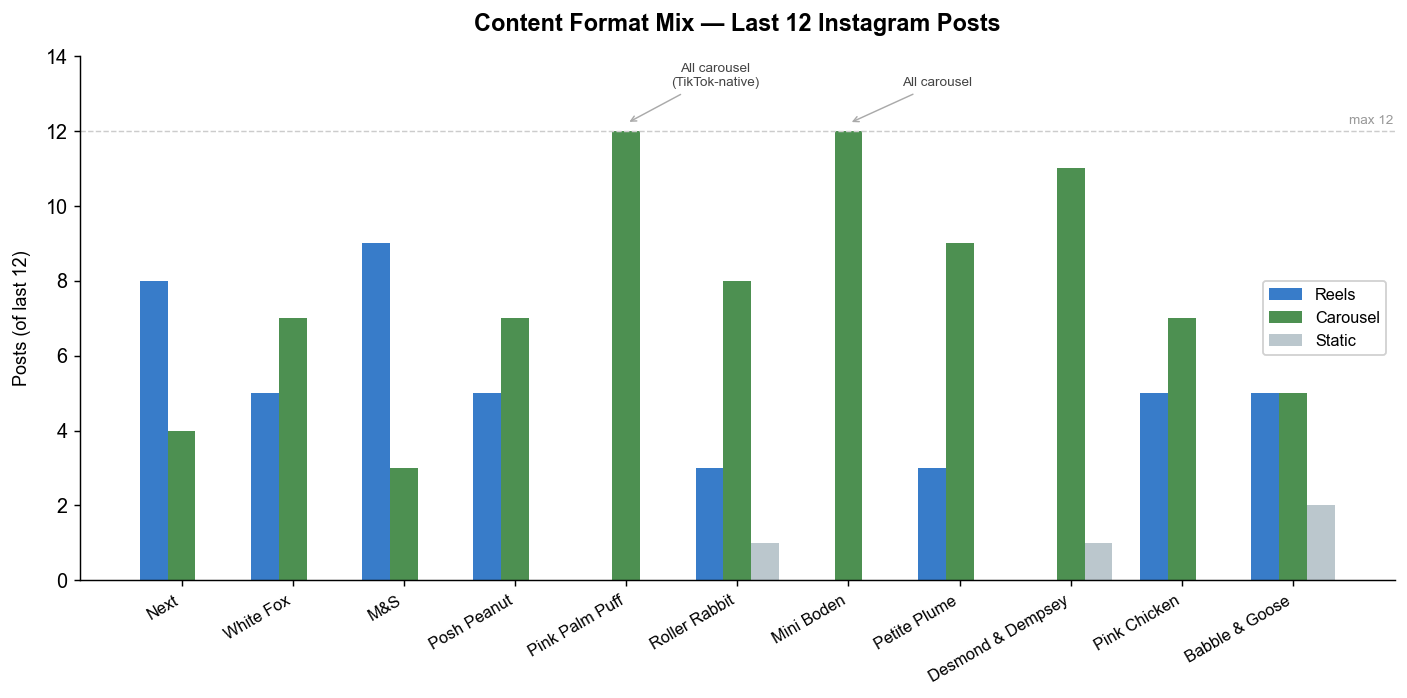

Saved: chart3_content_mix.png


In [5]:
fig, ax = plt.subplots(figsize=(11, 5.5))

d = df.sort_values('ig_followers', ascending=False).copy()
brands = d['brand'].tolist()
x = np.arange(len(brands))
width = 0.25

b1 = ax.bar(x - width, d['reels'],   width, label='Reels',   color='#1565C0', alpha=0.85)
b2 = ax.bar(x,         d['carousel'], width, label='Carousel', color='#2E7D32', alpha=0.85)
b3 = ax.bar(x + width, d['static'],  width, label='Static',  color='#B0BEC5', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(brands, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Posts (of last 12)', labelpad=8)
ax.set_title('Content Format Mix — Last 12 Instagram Posts', pad=14)
ax.set_ylim(0, 14)
ax.axhline(12, color='#cccccc', linewidth=0.8, linestyle='--')
ax.text(len(brands)-0.5, 12.2, 'max 12', fontsize=7.5, color='#999999')
ax.legend(fontsize=9, framealpha=0.9, edgecolor='#cccccc')

# Highlight PPP and Mini Boden as all-carousel
for brand, note in [('Pink Palm Puff', 'All carousel\n(TikTok-native)'), ('Mini Boden', 'All carousel')]:
    idx = brands.index(brand)
    ax.annotate(note, xy=(idx, 12.2), xytext=(idx + 0.8, 13.2),
                fontsize=7.5, color='#444444', ha='center',
                arrowprops=dict(arrowstyle='->', color='#aaaaaa', lw=0.8))

plt.tight_layout()
plt.savefig('chart3_content_mix.png')
plt.show()
print('Saved: chart3_content_mix.png')

The bar chart visualizes the content format distribution across the last 12 Instagram posts for each of the 11 kidswear/teen apparel brands (data from February 2026), stacked by format.  this chart captures a mature, strategic landscape: carousels have become the dominant, high-ROI format in this category (especially for premium storytelling), Reels remain essential for scale but not universal, and statics are effectively obsolete. Pink Palm Puff and similar all-carousel players are ahead of the curve, proving focused execution on the format Instagram rewards most in 2026.

**Strategic implications**

- 2026 algorithm reality — The chart shows brands converging on carousels as the "safe bet" for consistent performance in kidswear/teen apparel: they offer Reel-like reach (especially with music) + higher engagement depth than statics or even some Reels, without the full production burden. The near-absence of statics confirms single images are deprioritized unless part of a carousel.
- Format roles by objective — Reels for discovery/virality (mass brands lean in); carousels for education/trust/conversion (premiums dominate here); statics as legacy/minimal.
- Pink Palm Puff as case study — Its all-carousel feed reinforces its TikTok-native edge: short, swipeable, high-value posts translate seamlessly, yielding outsized engagement despite not being Reel-heavy on IG. This suggests a winning hybrid — borrow TikTok velocity for carousel depth — that other brands could emulate for efficiency and results.
- Bifurcation in approach — Larger accounts diversify (Reels + carousels); smaller/niche ones double down on carousels for loyalty and saves. The visual gap in static usage underscores how quickly the platform has shifted toward multi-format, interactive content.

---
## Chart 4 · Follower/Following Ratio — Brand Maturity Signal
A high ratio signals an established brand that earns followers organically. A low ratio suggests active follow-for-follow growth tactics.

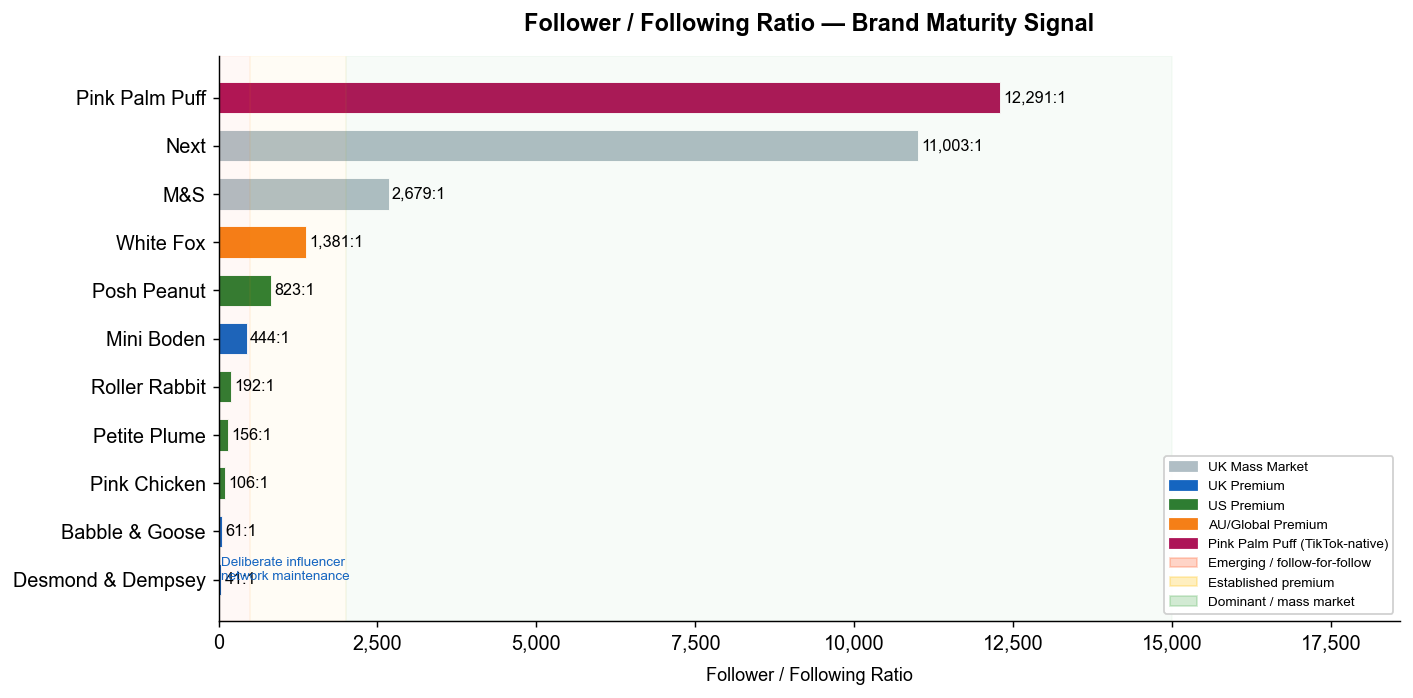

Saved: chart4_follower_ratio.png


In [6]:
fig, ax = plt.subplots(figsize=(11, 5.5))

d = df.sort_values('ratio', ascending=True).copy()

bars = ax.barh(d['brand'], d['ratio'],
               color=d['colour'], edgecolor='white', linewidth=0.5, height=0.65)

for bar, val in zip(bars, d['ratio']):
    ax.text(bar.get_width() + 50, bar.get_y() + bar.get_height()/2,
            f'{val:,.0f}:1', va='center', ha='left', fontsize=9)

# Maturity zones
ax.axvspan(0,    500,   alpha=0.04, color='#FF5722', label='Emerging / active following tactic')
ax.axvspan(500,  2000,  alpha=0.04, color='#FFC107', label='Established premium')
ax.axvspan(2000, 15000, alpha=0.04, color='#4CAF50', label='Dominant / mass market')

ax.set_xlabel('Follower / Following Ratio', labelpad=8)
ax.set_title('Follower / Following Ratio — Brand Maturity Signal', pad=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))
ax.set_xlim(0, ax.get_xlim()[1] * 1.18)

# Combine legends
zone_items = [
    mpatches.Patch(color='#FF5722', alpha=0.25, label='Emerging / follow-for-follow'),
    mpatches.Patch(color='#FFC107', alpha=0.25, label='Established premium'),
    mpatches.Patch(color='#4CAF50', alpha=0.25, label='Dominant / mass market'),
]
all_items = legend_items + zone_items
ax.legend(handles=all_items, fontsize=7.5, framealpha=0.9,
          edgecolor='#cccccc', loc='lower right')

# Note on D&D outlier
dd_idx = d[d['brand']=='Desmond & Dempsey'].index[0]
dd_pos = d.index.tolist().index(dd_idx) if dd_idx in d.index else None
# Annotate D&D low ratio
dd_row = d[d['brand']=='Desmond & Dempsey'].iloc[0]
ax.annotate('Deliberate influencer\nnetwork maintenance',
            xy=(dd_row['ratio'], d[d['brand']=='Desmond & Dempsey'].index[0] - d.index[0]),
            fontsize=7.5, color='#1565C0')

plt.tight_layout()
plt.savefig('chart4_follower_ratio.png')
plt.show()
print('Saved: chart4_follower_ratio.png')

The chart highlights a clear hierarchy with Pink Palm Puff emerging as the maturity standout — achieving dominant-zone status through exceptional organic pull and minimal following. This complements its other strengths (engagement, content mix) and positions it as a benchmark for how viral-native strategies can fast-track perceived authority in a competitive kidswear/teen space. Traditional mass players hold the top via legacy, but agile premiums like PPP are closing the gap dramatically.

**Strategic implications**

- High ratio = strong social proof — In 2026, brands with ratios >>1,000:1 (especially >5,000–10,000:1) project instant authority. Recruiters, partners, and consumers view them as influential without scrutiny. PPP's extreme ratio (despite mid-scale IG followers) proves TikTok-native virality + quality content can yield elite maturity signals faster than traditional paths.
- Mass vs. premium divide — UK mass-market brands dominate the top purely through scale and legacy. Premiums must earn high ratios via niche excellence, storytelling, and engagement (as PPP and White Fox demonstrate).
- Tactical vs. organic maturity — Low/negative ratios aren't automatically negative — they can indicate proactive growth phases (e.g., D&D's influencer focus). But as brands scale, shifting toward higher ratios (reducing outbound follows) boosts perceived prestige.
- Benchmark context — For brands/influencers in 2026, ratios >2:1–5:1 are solid; >10:1 is elite for non-celebrity accounts. Anything <1:1 often signals early-stage or heavy reciprocity tactics.

---
## Chart 5 · TikTok vs Instagram Followers — Platform Balance
Where do brands live? Most premium brands are Instagram-dominant. Pink Palm Puff is the outlier — TikTok is clearly the primary platform.

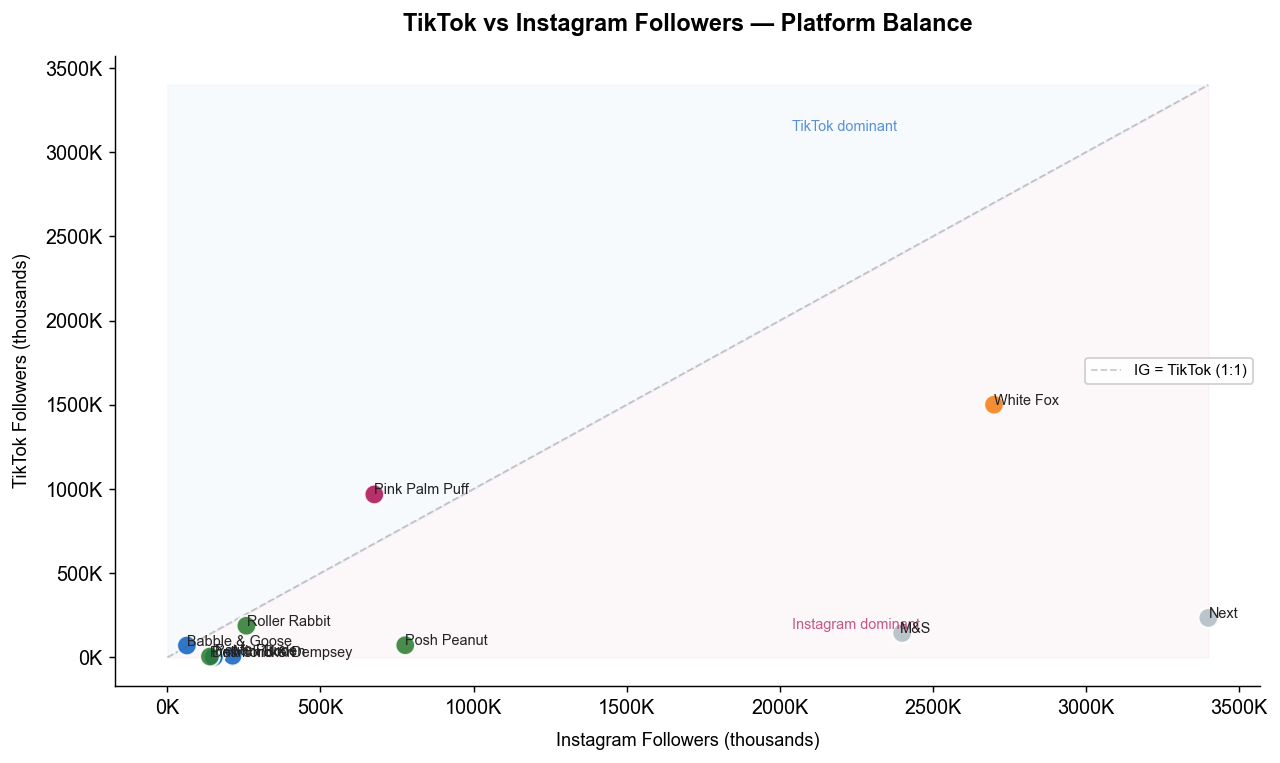

Saved: chart5_tiktok_vs_ig.png


In [7]:
fig, ax = plt.subplots(figsize=(10, 6))

d = df.copy()

ax.scatter(
    d['ig_followers'] / 1e3,
    d['tt_followers'] / 1e3,
    s=120,
    c=d['colour'],
    alpha=0.88,
    edgecolors='white',
    linewidths=1.2,
    zorder=3
)

# 1:1 line — equal Instagram and TikTok
max_val = max(d['ig_followers'].max(), d['tt_followers'].max()) / 1e3
ax.plot([0, max_val], [0, max_val], '--', color='#cccccc', linewidth=1, zorder=1, label='IG = TikTok (1:1)')
ax.fill_between([0, max_val], [0, max_val], max_val, alpha=0.03, color='#1565C0')
ax.fill_between([0, max_val], 0, [0, max_val], alpha=0.03, color='#AD1457')

ax.text(max_val*0.6, max_val*0.92, 'TikTok dominant', fontsize=8, color='#1565C0', alpha=0.7)
ax.text(max_val*0.6, max_val*0.05, 'Instagram dominant', fontsize=8, color='#AD1457', alpha=0.7)

# Brand labels
label_offsets = {
    'Pink Palm Puff':    (20,  20),
    'White Fox':         (20,  20),
    'M&S':               (-250, 20),
    'Next':              (20, -40),
    'Posh Peanut':       (20,  15),
    'Roller Rabbit':     (20,  15),
    'Babble & Goose':    (20, -35),
    'Mini Boden':        (20,  15),
    'Petite Plume':      (20, -35),
    'Desmond & Dempsey': (-270, 15),
    'Pink Chicken':      (20,  15),
}

for _, row in d.iterrows():
    ox, oy = label_offsets.get(row['brand'], (10, 10))
    ax.annotate(
        row['brand'],
        xy=(row['ig_followers']/1e3, row['tt_followers']/1e3),
        xytext=(row['ig_followers']/1e3 + ox/40, row['tt_followers']/1e3 + oy/40),
        fontsize=8,
        color='#222222'
    )

ax.set_xlabel('Instagram Followers (thousands)', labelpad=8)
ax.set_ylabel('TikTok Followers (thousands)', labelpad=8)
ax.set_title('TikTok vs Instagram Followers — Platform Balance', pad=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))

ax.legend(fontsize=8.5, framealpha=0.9, edgecolor='#cccccc')

plt.tight_layout()
plt.savefig('chart5_tiktok_vs_ig.png')
plt.show()
print('Saved: chart5_tiktok_vs_ig.png')

The plot captures a transitional moment in 2026: Instagram-dominant for most (especially mass/established), but TikTok-dominant strategies (exemplified by Pink Palm Puff) offer a clear path to disruption — higher velocity, better engagement quality, and potential to leapfrog traditional scale via short-form virality. PPP's placement above the line, combined with its other metrics, makes it the clearest success story for cross-platform balance in this competitive kidswear/teen category.

**Strategic insights**

- Instagram still rules for scale in kidswear/teen apparel (2026 reality) — The right-heavy distribution (most points below the line) shows IG as the primary visibility and conversion driver, especially for established/mass players. TikTok's algorithm favors discovery and virality but hasn't fully displaced IG for broad follower accumulation in this demographic (parents + teens).
- TikTok as a differentiator for agile premiums — PPP and White Fox prove that leaning into TikTok can yield outsized results: faster growth, higher engagement (from prior chart), and cross-pollination to IG. PPP's position is particularly impressive — achieving meaningful IG scale while being TT-dominant highlights a winning hybrid model: build virality on TikTok → funnel loyal fans to IG for deeper e-commerce/brand storytelling.
- **Risk of platform imbalance** — Brands deep in the bottom-right (high IG, low TT) may miss Gen Alpha/Gen Z trends shifting toward short-form video. Conversely, pure TikTok plays risk weaker e-commerce infrastructure on IG.
- Cross-platform maturity signal — The chart reinforces PPP as the strategic outlier: not just high engagement and maturity signals (from earlier visuals), but a deliberate TT-first approach that still delivers competitive IG reach. This positions it ahead in a bifurcated landscape — mass brands dominate IG volume; viral-natives like PPP win on momentum and efficiency.

---
## Chart 6 · TikTok Average Video Views
Views per video reveal content resonance independent of follower count — the real measure of TikTok reach.

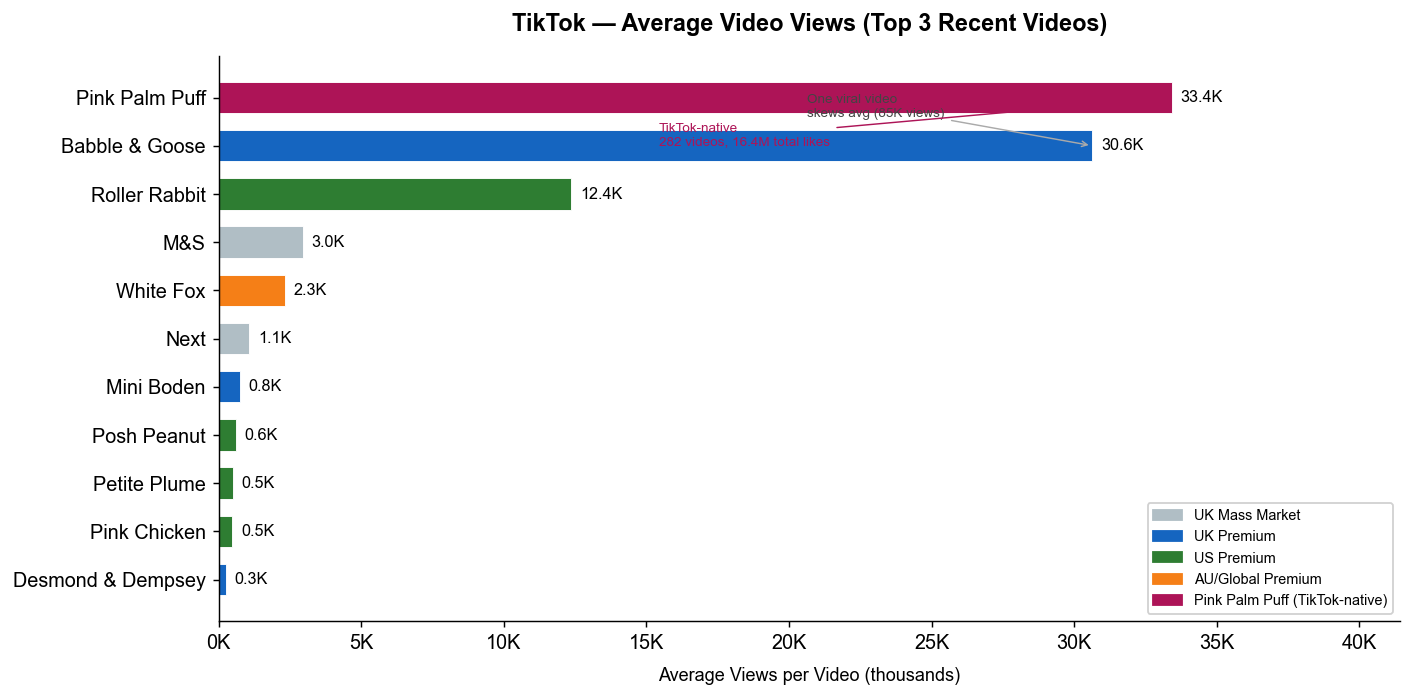

Saved: chart6_tiktok_views.png


In [8]:
fig, ax = plt.subplots(figsize=(11, 5.5))

d = df.sort_values('tt_avg_views', ascending=True).copy()

bars = ax.barh(d['brand'], d['tt_avg_views'] / 1e3,
               color=d['colour'], edgecolor='white', linewidth=0.5, height=0.65)

for bar, val in zip(bars, d['tt_avg_views']):
    label = f'{val/1e3:.1f}K'
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            label, va='center', ha='left', fontsize=9)

ax.set_xlabel('Average Views per Video (thousands)', labelpad=8)
ax.set_title('TikTok — Average Video Views (Top 3 Recent Videos)', pad=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.0f}K'))
ax.set_xlim(0, ax.get_xlim()[1] * 1.18)

# Babble & Goose outlier note
bg = d[d['brand']=='Babble & Goose'].iloc[0]
bg_y = d[d['brand']=='Babble & Goose'].index[0] - d.index[0]
# Just annotate by searching
for i, (_, row) in enumerate(d.iterrows()):
    if row['brand'] == 'Babble & Goose':
        ax.annotate('One viral video\nskews avg (85K views)',
                    xy=(row['tt_avg_views']/1e3, i),
                    xytext=(row['tt_avg_views']/1e3 - 10, i + 0.6),
                    fontsize=7.5, color='#444444',
                    arrowprops=dict(arrowstyle='->', color='#aaaaaa', lw=0.8))
    if row['brand'] == 'Pink Palm Puff':
        ax.annotate('TikTok-native\n282 videos, 16.4M total likes',
                    xy=(row['tt_avg_views']/1e3, i),
                    xytext=(row['tt_avg_views']/1e3 - 18, i - 1),
                    fontsize=7.5, color=COLOURS['ppp'],
                    arrowprops=dict(arrowstyle='->', color=COLOURS['ppp'], lw=0.8))

ax.legend(handles=legend_items, fontsize=8, framealpha=0.9,
          edgecolor='#cccccc', loc='lower right')

plt.tight_layout()
plt.savefig('chart6_tiktok_views.png')
plt.show()
print('Saved: chart6_tiktok_views.png')

The chart cements Pink Palm Puff as the TikTok standout in the dataset: exceptional recent-view performance driven by native strategy and consistency, far ahead of even breakout globals (White Fox) or legacy mass players. It underscores TikTok's role as a true differentiator — where most brands underperform, a focused native approach can generate disproportionate visibility and momentum.

**Strategic takeaways**

- TikTok performance is highly uneven in this kidswear/teen apparel category (2026 data):
Only 2–3 brands achieve meaningful view velocity (>10K avg per recent video). Most premiums treat TikTok as an afterthought, resulting in sub-1K–3K views — far below what's needed for sustained discovery or cross-pollination to IG.
- Pink Palm Puff's TikTok dominance is reinforced — High average views on recent content, paired with massive total likes (16.4M across 282 videos), confirm a flywheel effect: consistent posting → algorithmic favor → reliable reach → follower growth → cross-platform leverage to IG. This explains why PPP punches above its weight across every prior metric (engagement, maturity signal, content mix). It's the clearest proof that a short-form-first, TikTok-native approach delivers outsized results in a niche teen/kidswear space.
- Viral spikes vs. consistency — Babble & Goose's skew from one 85K-view hit shows how a single strong video can temporarily inflate metrics, but without volume/follow-through, it doesn't translate to sustained momentum (unlike PPP). Roller Rabbit's mid-tier performance suggests niche appeal can work on TikTok, but scale requires more native optimization.
- Mass-market lag on TikTok — Next and M&S's low views highlight a strategic gap: despite household-name status and massive IG audiences, they haven't cracked TikTok's algorithm or Gen Z/Alpha content style. This leaves room for agile premiums (PPP, potentially White Fox) to capture younger audiences and future market share.
- **Implication for new entrants** — In 2026, TikTok remains the highest-upside platform for rapid reach in teen/kidswear — but only if executed with high posting cadence, trend participation, and format mastery. Brands stuck below ~5K avg views per recent video are effectively invisible on the platform, limiting their ability to compete with viral-natives like PPP.

---
## Chart 7 · Cross-Platform Summary — Total Reach
Stacked view of IG + TikTok combined reach per brand.

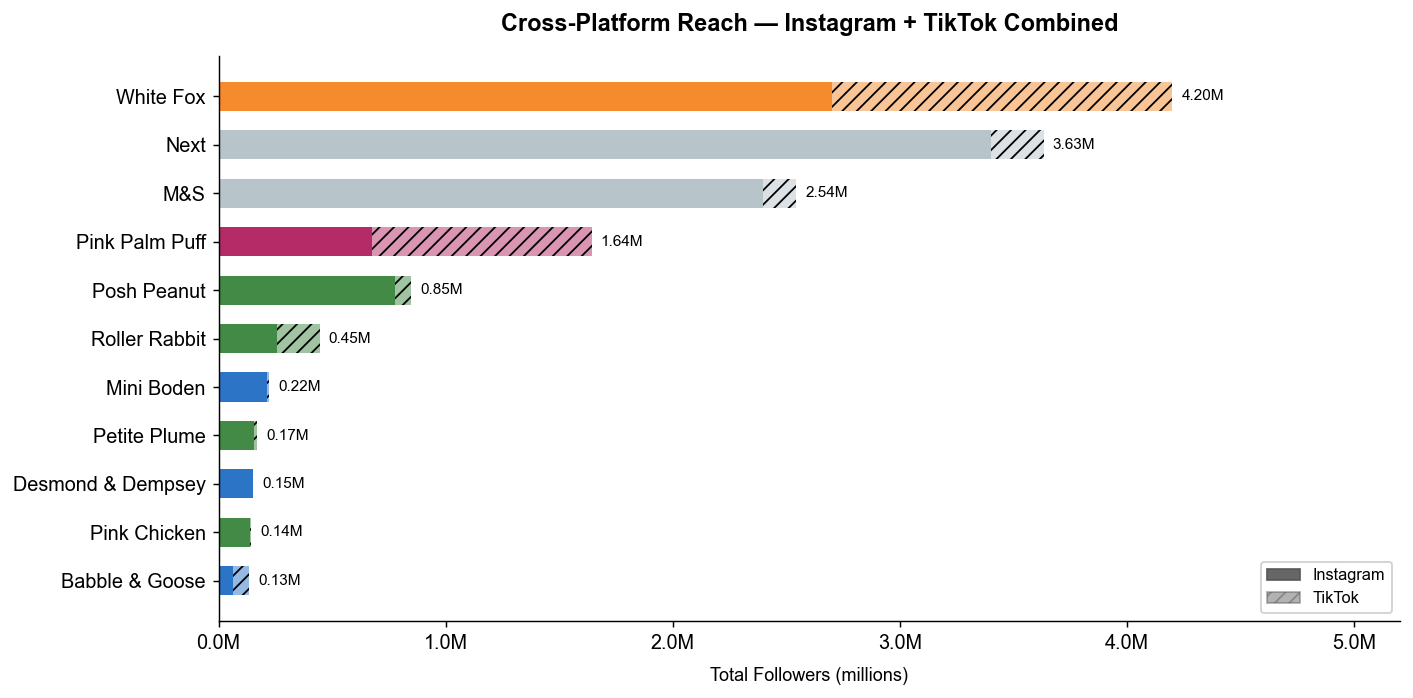

Saved: chart7_total_reach.png


In [9]:
fig, ax = plt.subplots(figsize=(11, 5.5))

d = df.sort_values('total_followers', ascending=True).copy()
ig_vals = d['ig_followers'].fillna(0) / 1e6
tt_vals = d['tt_followers'].fillna(0) / 1e6

bars1 = ax.barh(d['brand'], ig_vals, height=0.6,
                color=d['colour'], alpha=0.9, label='Instagram')
bars2 = ax.barh(d['brand'], tt_vals, height=0.6, left=ig_vals,
                color=d['colour'], alpha=0.45, hatch='///', label='TikTok')

# Total label at end
for _, row in d.iterrows():
    total = (row['ig_followers'] + row['tt_followers']) / 1e6
    label = f'{total:.2f}M' if total >= 0.1 else f'{total*1000:.0f}K'
    ax.text(total + 0.04, list(d['brand']).index(row['brand']),
            label, va='center', ha='left', fontsize=8.5)

ax.set_xlabel('Total Followers (millions)', labelpad=8)
ax.set_title('Cross-Platform Reach — Instagram + TikTok Combined', pad=14)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:.1f}M'))
ax.set_xlim(0, ax.get_xlim()[1] * 1.18)

# Custom legend
ig_patch = mpatches.Patch(color='#555555', alpha=0.9, label='Instagram')
tt_patch = mpatches.Patch(color='#555555', alpha=0.45, hatch='///', label='TikTok')
ax.legend(handles=[ig_patch, tt_patch], fontsize=9,
          framealpha=0.9, edgecolor='#cccccc', loc='lower right')

plt.tight_layout()
plt.savefig('chart7_total_reach.png')
plt.show()
print('Saved: chart7_total_reach.png')

This visual reinforces the strategic value of platform balance — especially TikTok investment — for brands aiming to compete beyond niche Instagram audiences. White Fox sets the high bar for global premium scale; PPP demonstrates how a focused, viral-native approach can deliver outsized cross-platform impact.

A two-tier reality in cross-platform social reach:

- A small group of scale-dominant players (White Fox leading via dual-platform strength, followed by IG-heavy mass-market giants).
- Pink Palm Puff as the standout premium disruptor, using TikTok dominance to close the gap dramatically on total audience despite mid-tier Instagram numbers.

---
## Key Findings

In [11]:
print('=' * 70)
print('KEY FINDINGS — Social Media Analysis')
print('=' * 70)
print('\n1. SCALE GAP: Mass market (M&S 2.4M, Next 3.4M) vs UK premium')
print(f' (Mini Boden 213K, D&D 152K) — 10x+ follower gap on Instagram.')
print(f' UK premium brands remain small by global standards.')
print('\n2. ENGAGEMENT INVERSE: Smaller brands punch above their weight.')
d_eng = df.dropna(subset=['eng_rate']).sort_values('eng_rate', ascending=False)
for _, row in d_eng.iterrows():
    print(f' {row["brand"]:<22} {row["ig_followers"]/1e3:>7.0f}K followers '
          f'eng rate: {row["eng_rate"]:>6.3f}%')
print('\n3. CONTENT FORMAT: Static posts essentially dead across all brands.')
print(f' Carousel dominant overall (especially in premium for multi-image storytelling,')
print(f' authenticity, and depth). Reels used more aggressively by mass-market brands')
print(f' and breakout globals like White Fox for algorithmic reach/discovery.')
print('\n4. TIKTOK DIVIDE:')
print(f' UK brands largely absent or negligible on TikTok:')
for _, row in df[df['market'].str.contains('UK')].sort_values('tt_followers').iterrows():
    print(f' {row["brand"]:<22} TikTok: {row["tt_followers"]/1e3:>7.1f}K IG: {row["ig_followers"]/1e3:>7.1f}K')
print('\n5. PINK PALM PUFF — CASE STUDY:')
ppp = df[df['brand']=='Pink Palm Puff'].iloc[0]
print(f' TikTok: {ppp["tt_followers"]/1e3:.0f}K followers | IG: {ppp["ig_followers"]/1e3:.0f}K followers')
print(f' Engagement rate: {ppp["eng_rate"]:.3f}% — highest in dataset')
print(f' Follower/following ratio: {ppp["ratio"]:,.0f}:1 — signals strong organic earned growth')
print(f' All-carousel IG content. TikTok-native founder-as-influencer model.')
print(f' Expanded from hoodies into matching pyjamas/loungewear due to teen audience demand.')
print(f' IMPLICATION: Demonstrates strong performance potential for authentic,')
print(f' founder-led premium content targeting teens at ~$89/£65+ price point.')
print('\n6. UK PREMIUM BRANDS REVIEWED:')
print(' Brands positioned in/near the teen 11–19 premium loungewear space:')
print(' ┌─────────────────────┬──────────────────────────────────────────────────────┐')
print(' │ Brand               │ Verdict                                              │')
print(' ├─────────────────────┼──────────────────────────────────────────────────────┤')
print(' │ Mini Boden          │ UK premium kids — stops at ~age 11                   │')
print(' │ Desmond & Dempsey   │ UK premium adult — kids line 0–10 only               │')
print(' │ Pull & Bear         │ Teen age group ✓ — fast fashion (£15–25), not premium│')
print(' │ Adanola             │ Premium price ✓, social ✓ — adult activewear, no PJ  │')
print(' │ Skinnydip London    │ Teen-coded nightwear ✓ (pyjama sets available) — more│')
print(' │                     │ playful/character-driven, less £55–85 premium focus  │')
print(' │ Nobody\'s Child      │ Adult womenswear only — not relevant                 │')
print(' │ Ava & Bear London   │ UK premium kids sleepwear — stops at ~age 10         │')
print(' └─────────────────────┴──────────────────────────────────────────────────────┘')
print('=' * 70)

KEY FINDINGS — Social Media Analysis

1. SCALE GAP: Mass market (M&S 2.4M, Next 3.4M) vs UK premium
 (Mini Boden 213K, D&D 152K) — 10x+ follower gap on Instagram.
 UK premium brands remain small by global standards.

2. ENGAGEMENT INVERSE: Smaller brands punch above their weight.
 Pink Palm Puff             676K followers eng rate:  2.366%
 Roller Rabbit              258K followers eng rate:  1.157%
 Desmond & Dempsey          152K followers eng rate:  0.197%
 Babble & Goose              64K followers eng rate:  0.182%
 White Fox                 2700K followers eng rate:  0.062%
 Posh Peanut                777K followers eng rate:  0.056%
 M&S                       2400K followers eng rate:  0.048%
 Next                      3400K followers eng rate:  0.019%

3. CONTENT FORMAT: Static posts essentially dead across all brands.
 Carousel dominant overall (especially in premium for multi-image storytelling,
 authenticity, and depth). Reels used more aggressively by mass-market brands
 and